📊 สรุปผล: 4 Random vs 1 No-Limit vs 1 Capped (10,000 รอบ)
💰 เติมกองกลางไปทั้งหมด: 10 ครั้ง
--------------------------------------------------
🐟 P1 (สายเล่นมั่ว):   -625,125 บาท
🐟 P2 (สายเล่นมั่ว):   -657,227 บาท
🐟 P3 (สายเล่นมั่ว):   -567,081 บาท
🐟 P4 (สายเล่นมั่ว):   -624,939 บาท
🦈 P5 (No-Limit Kelly): 1,685,629 บาท
🦈 P6 (Max 3,000 Kelly):  771,511 บาท


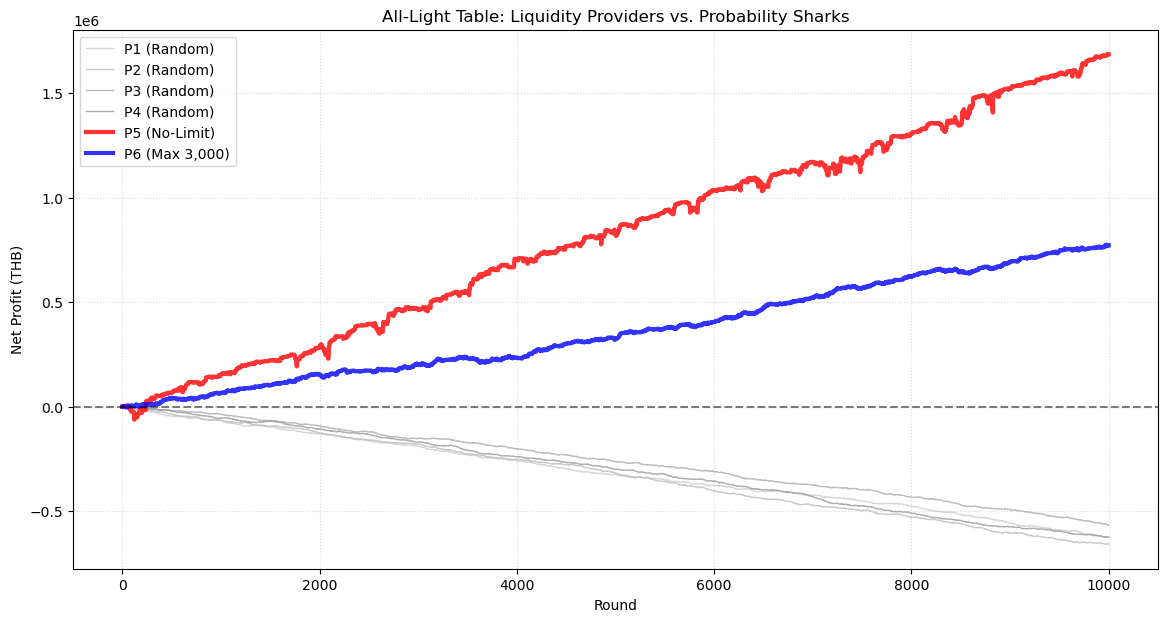

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- การตั้งค่า (Configuration) ---
ITERATIONS = 10000        # จำนวนรอบที่จะจำลอง
NUM_PLAYERS = 6           # ผู้เล่น 6 คน
BUY_IN = 200              # ค่าเติมกองกลาง (200 บาท)
HAND_SIZE = 4             # กติกาแจก 4 ใบ

def is_win(hand, center):
    c_rank, c_suit = center
    for p_rank, p_suit in hand:
        if p_suit == c_suit:
            if p_rank == 2 and c_rank == 14: return True
            if p_rank == 14 and c_rank == 2: continue
            if p_rank > c_rank: return True
    return False

# ฟังก์ชันคำนวณโอกาสชนะจากไพ่ 4 ใบ
def calc_win_prob(hand):
    deck_base = [(r, s) for r in range(2, 15) for s in ['C', 'D', 'H', 'S']]
    unknown_cards = [c for c in deck_base if c not in hand]
    wins = sum(1 for center in unknown_cards if is_win(hand, center))
    return wins / len(unknown_cards)

def simulate_all_light_sharks():
    deck_base = [(r, s) for r in range(2, 15) for s in ['C', 'D', 'H', 'S']]
    balances = np.zeros(NUM_PLAYERS)
    pot = NUM_PLAYERS * BUY_IN
    balances -= BUY_IN
    
    history = [balances.copy()]
    pot_refills = 0

    for _ in range(ITERATIONS):
        deck = deck_base[:]
        random.shuffle(deck)
        center = deck[0]
        hands = [deck[1 + i*HAND_SIZE : 1 + (i+1)*HAND_SIZE] for i in range(NUM_PLAYERS)]
        
        for i in range(NUM_PLAYERS):
            # 🛑 เช็กกองกลาง ถ้าหมดให้เติม
            if pot <= 0:
                pot_refills += 1
                balances -= BUY_IN
                pot += NUM_PLAYERS * BUY_IN
                
            hand = hands[i]
            won = is_win(hand, center)
            bet_amount = 0
            
            if i < 4:
                # P1 - P4: สายเล่นมั่ว (สุ่มเล่น 50% แทง 500 บาท)
                if random.random() > 0.5:
                    bet_amount = min(500, pot)
            else:
                # P5 - P6: สายสว่างนับไพ่ (Kelly Criterion)
                p_win = calc_win_prob(hand)
                
                if p_win > 0.5: # สู้เมื่อได้เปรียบเท่านั้น
                    kelly_fraction = (2 * p_win) - 1
                    bet_amount = int(pot * kelly_fraction)
                    bet_amount = min(bet_amount, pot) # ห้ามแทงเกินกองกลาง
                    
                    if i == 5:
                        # P6: Capped Shark มีเพดานที่ 3,000 บาท
                        bet_amount = min(bet_amount, 3000)
                else:
                    bet_amount = 0 # โอกาสน้อยกว่า 50% คือหมอบ
            
            # 🛑 คำนวณเงินเมื่อมีการแทง (ทุกแบบสว่าง เสียเต็ม)
            if bet_amount > 0:
                if won:
                    balances[i] += bet_amount
                    pot -= bet_amount
                else:
                    balances[i] -= bet_amount
                    pot += bet_amount
                    
        history.append(balances.copy())

    return np.array(history), pot_refills

# --- รัน Simulation ---
history_data, total_refills = simulate_all_light_sharks()

# --- สรุปผล ---
print(f"==================================================")
print(f"📊 สรุปผล: 4 Random vs 1 No-Limit vs 1 Capped ({ITERATIONS:,} รอบ)")
print(f"💰 เติมกองกลางไปทั้งหมด: {total_refills:,} ครั้ง")
print(f"--------------------------------------------------")
for i in range(4):
    print(f"🐟 P{i+1} (สายเล่นมั่ว): {history_data[-1][i]:>10,.0f} บาท")
print(f"🦈 P5 (No-Limit Kelly): {history_data[-1][4]:>9,.0f} บาท")
print(f"🦈 P6 (Max 3,000 Kelly): {history_data[-1][5]:>8,.0f} บาท")
print(f"==================================================")

# --- พล็อตกราฟ ---
plt.figure(figsize=(14, 7))
colors = ['#cccccc', '#bbbbbb', '#aaaaaa', '#999999', '#ff0000', '#0000ff']
labels = ['P1 (Random)', 'P2 (Random)', 'P3 (Random)', 'P4 (Random)', 'P5 (No-Limit)', 'P6 (Max 3,000)']
linewidths = [1, 1, 1, 1, 3, 3]

for i in range(NUM_PLAYERS):
    plt.plot(history_data[:, i], label=labels[i], color=colors[i], linewidth=linewidths[i], alpha=0.8)

plt.title('All-Light Table: Liquidity Providers vs. Probability Sharks')
plt.xlabel('Round')
plt.ylabel('Net Profit (THB)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()